In [2]:
#Imports and Dataset Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
ds = load_dataset("stanfordnlp/imdb")
print(ds)

# Dataset splits
print("\nTrain size:", len(ds["train"]))
print("Test size:", len(ds["test"]))


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Train size: 25000
Test size: 25000


Label distribution:
 label
0    12500
1    12500
Name: count, dtype: int64


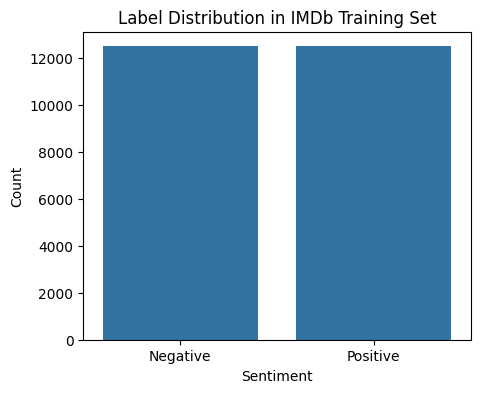

In [3]:
#Dataset Exploration

# Convert training set to pandas
train_df = pd.DataFrame(ds["train"])

# Label distribution
label_counts = train_df["label"].value_counts()
print("Label distribution:\n", label_counts)

# Plot label distribution
plt.figure(figsize=(5,4))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks([0,1], ["Negative", "Positive"])
plt.title("Label Distribution in IMDb Training Set")
plt.ylabel("Count")
plt.xlabel("Sentiment")
plt.show()



Review length statistics:
count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: review_length, dtype: float64


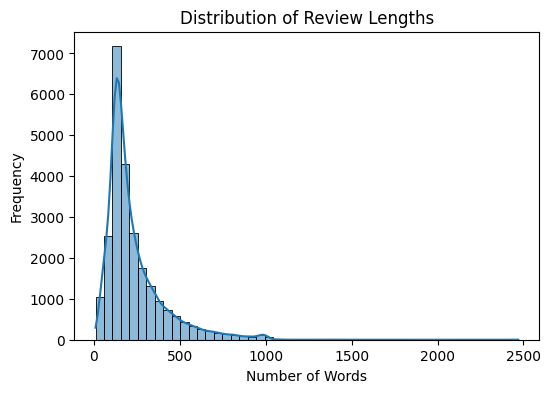

In [4]:
# Review length analysis (number of words)
train_df["review_length"] = train_df["text"].apply(lambda x: len(x.split()))
print("\nReview length statistics:")
print(train_df["review_length"].describe())

# Plot review length distribution
plt.figure(figsize=(6,4))
sns.histplot(train_df["review_length"], bins=50, kde=True)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [7]:
# Text Preprocessing (Tokenization & Padding)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Parameters
VOCAB_SIZE = 20000
MAX_LENGTH = 300
OOV_TOKEN = "<OOV>"

# Convert Hugging Face dataset columns to lists
texts = list(ds["train"]["text"])
labels = list(ds["train"]["label"])

# Train-validation split
train_texts, val_texts, train_labels, val_labels = train_test_split(texts,labels,
    test_size=0.2,random_state=42)

# Initialize tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)

# Fit tokenizer on training text only
tokenizer.fit_on_texts(train_texts)

# Convert text to sequences
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(ds["test"]["text"])

# Pad sequences
X_train = pad_sequences(train_sequences, maxlen=MAX_LENGTH, padding="post", truncating="post")
X_val = pad_sequences(val_sequences, maxlen=MAX_LENGTH, padding="post", truncating="post")
X_test = pad_sequences(test_sequences, maxlen=MAX_LENGTH, padding="post", truncating="post")

# Labels
y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(ds["test"]["label"])

#check shapes
print("Training data shape:", X_train.shape)
print("Validation data shape:", X_val.shape)
print("Test data shape:", X_test.shape)

Training data shape: (20000, 300)
Validation data shape: (5000, 300)
Test data shape: (25000, 300)


In [ ]:
"""
The training data was split into training and validation sets using an 80/20 split.
Dataset columns were converted to standard Python lists to ensure compatibility with scikit-learn utilities.
"""

In [9]:
#Build the Deep Learning Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
"""
A bidirectional LSTM model was used to capture contextual information in movie reviews.
An embedding layer was employed to learn dense vector representations of words, followed by a bidirectional LSTM to model sequential dependencies.
Dropout was applied to reduce overfitting, and a sigmoid-activated output layer was used for binary sentiment classification.
"""

In [10]:
#Model Training
EPOCHS = 5
BATCH_SIZE = 64

history = model.fit(X_train, y_train,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=(X_val, y_val))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 205s 640ms/step - accuracy: 0.6443 - loss: 0.5965 - val_accuracy: 0.7954 - val_loss: 0.5249
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 631ms/step - accuracy: 0.8674 - loss: 0.3467 - val_accuracy: 0.8324 - val_loss: 0.3995
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 635ms/step - accuracy: 0.9232 - loss: 0.2157 - val_accuracy: 0.8744 - val_loss: 0.3445
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 200s 629ms/step - accuracy: 0.9492 - loss: 0.1540 - val_accuracy: 0.8674 - val_loss: 0.3603
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 202s 628ms/step - accuracy: 0.9614 - loss: 0.1186 - val_accuracy: 0.8682 - val_loss: 0.4442


In [ ]:
"""
The model achieved a training accuracy of 96.1% and a validation accuracy of 86.8%.
While training accuracy continued to improve across epochs, validation accuracy plateaued after the third epoch, indicating mild overfitting.
Expected for text classification tasks and suggests the model successfully learned meaningful sentiment patterns.
"""

In [11]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Predict probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step
Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.91      0.84     12500
           1       0.89      0.75      0.81     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



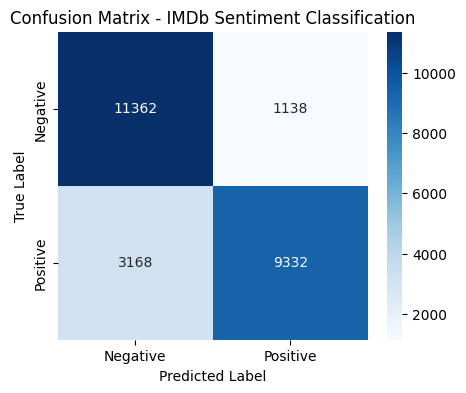

In [12]:
# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - IMDb Sentiment Classification")
plt.show()

In [ ]:
"""
The model is better at detecting negative sentiment than positive
Positive reviews are more linguistically diverse → harder to classify
"""

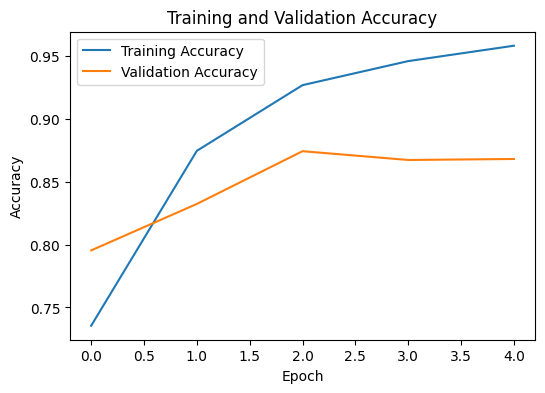

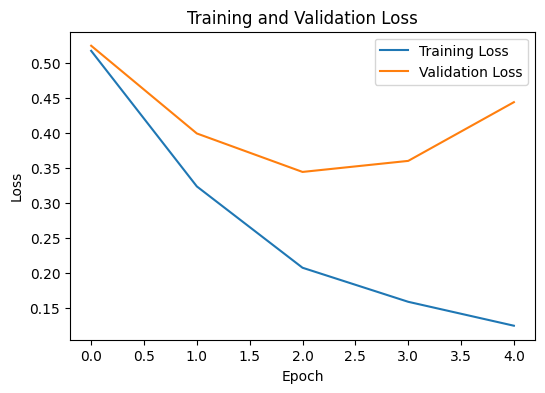

In [13]:
# Training Curves

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
"""
Accuracy Curve
Training accuracy steadily increases to ~96%
Validation accuracy peaks around ~87%
Gap after epoch 2–3 → mild overfitting

Loss Curve
Training loss consistently decreases
Validation loss decreases until epoch 2
Then starts increasing → classic overfitting signal
"""